# Day06下午个人项目：电商用户数据可视化

姓名/学号或GitHub用户名：24012429  
第5天专题（A/B/C/D/E）：A

本Notebook需要完成4张独立图、1张综合图和1份图表清单。请阅读`docs/day06_student_visualization_manual.md`后开始。


## 项目规则

1. 使用第4天清洗数据，并核对第5天个人分析结果；
2. 柱状图和散点图必做；折线图只能用于时间或有序阶段；
3. 饼图只用于少量类别的整体构成，必要时改用柱状图；
4. 每张图写“观察—证据—边界”；
5. 输出文件名和目录不得修改，以便第7天Flask直接复用。


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

STUDENT_ID = "24012429"
TOPIC = "A"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "PingFang SC",
    "Heiti SC", "Arial Unicode MS", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "output" / "day04_project" / "ecommerce_customer_cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("未找到第4天清洗数据，请先完成Day04。")


ROOT = find_workspace_root()
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输出：", OUTPUT_DIR.relative_to(ROOT))


学生： 24012429
专题： A
输出： output\day06_visualization


## 检查点1：输入与业务问题

先验证4个输入文件，再写出4个问题。不要在尚未理解指标时直接绘图。


In [2]:
required_inputs = [
    DATA_PATH,
    DAY05_DIR / "overall_metrics.csv",
    DAY05_DIR / "segment_analysis.csv",
    DAY05_DIR / "cross_analysis.csv",
]
missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

df = pd.read_csv(DATA_PATH)
tenure_order = ["新用户", "0-6个月", "7-12个月", "13-24个月", "24个月以上"]
df["TenureGroup"] = pd.Categorical(
    df["TenureGroup"],
    categories=tenure_order,
    ordered=True
)
overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])

assert df.shape[0] == 5630, f"清洗数据行数异常：{df.shape}"
assert {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}.issubset(df.columns)
assert set(df["Churn"].dropna().unique()).issubset({0, 1})

display(overall_metrics)
display(segment_analysis.head())
display(cross_analysis.head())
print("检查点1A通过：输入文件有效")


,指标,数值
0,用户数,"5,630.00"
1,流失人数,948.00
2,流失率,0.17
3,平均订单数,2.96
4,订单数中位数,2.00
5,平均优惠券数,1.72
6,平均返现,177.22
7,平均App时长,2.93
8,平均满意度,3.07
9,平均距上次下单天数,4.46


,TenureGroup,用户数,流失人数,平均订单数,平均App使用时长,平均满意度
0,0-6个月,1642,425,2.68,3.14,3.09
1,13-24个月,1467,95,3.70,2.94,3.09
2,24个月以上,429,0,3.55,2.87,3.05
3,7-12个月,1584,156,2.75,2.88,2.99
4,新用户,508,272,1.89,2.51,3.18


,TenureGroup,Complain,用户数,流失人数,流失率,平均订单数,样本提示
0,新用户,1,194,139,0.72,2.12,可观察
1,0-6个月,1,465,236,0.51,2.87,可观察
2,新用户,0,314,133,0.42,1.75,可观察
3,7-12个月,1,406,81,0.20,2.67,可观察
4,0-6个月,0,1177,189,0.16,2.61,可观察


检查点1A通过：输入文件有效


In [3]:
# TODO：填写4个业务问题和图表选择理由
business_questions = {
    "category_bar": "不同用户生命周期分组的整体流失率存在怎样差异？",
    "behavior_scatter": "用户平均App使用时长和流失率之间是否存在关联趋势？",
    "ordered_line": "随着用户生命周期增长，用户平均订单数呈现什么样的变化规律？",
    "composition_chart": "整体流失用户中，各生命周期用户群体的占比结构是怎样的？",
}

chart_reasons = {
    "category_bar": "柱状图适合对比不同分类（生命周期分组）的指标数值差异，直观查看各组流失率差距",
    "behavior_scatter": "散点图适合查看两个连续数值变量之间的相关分布，观察App使用时长与流失率的相关性",
    "ordered_line": "折线图适合展示有序类别（生命周期）下指标变化趋势，清晰体现订单数随生命周期的变化",
    "composition_chart": "构成图（饼图/堆叠柱状图）适合展示整体内部各分组占比，直观查看流失用户的结构构成",
}

assert all(text.strip() for text in business_questions.values()), "请填写4个业务问题"
assert all(text.strip() for text in chart_reasons.values()), "请填写4个图表选择理由"
print("检查点1B通过：业务问题和选择理由已填写")


检查点1B通过：业务问题和选择理由已填写


## 任务1：类别比较柱状图

要求：选择一个离散分组字段，计算用户数和一个核心指标；若绘制比率，标签中必须同时给出样本量。


In [4]:
# TODO：完成绘图数据。建议使用自己的第5天主分组字段。
category_field = "TenureGroup"
category_summary = (
    df.groupby(category_field, observed=True)
    .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
    .reset_index()
)

# 参考结构，不是答案：
# category_summary = (
#     df.groupby(category_field, observed=True)
#       .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
#       .reset_index()
# )

assert category_field in df.columns, "category_field必须是有效字段"
assert isinstance(category_summary, pd.DataFrame), "category_summary必须是DataFrame"
assert {category_field, "用户数"}.issubset(category_summary.columns)
display(category_summary)


,TenureGroup,用户数,流失率
0,新用户,508,0.54
1,0-6个月,1642,0.26
2,7-12个月,1584,0.10
3,13-24个月,1467,0.06
4,24个月以上,429,0.00


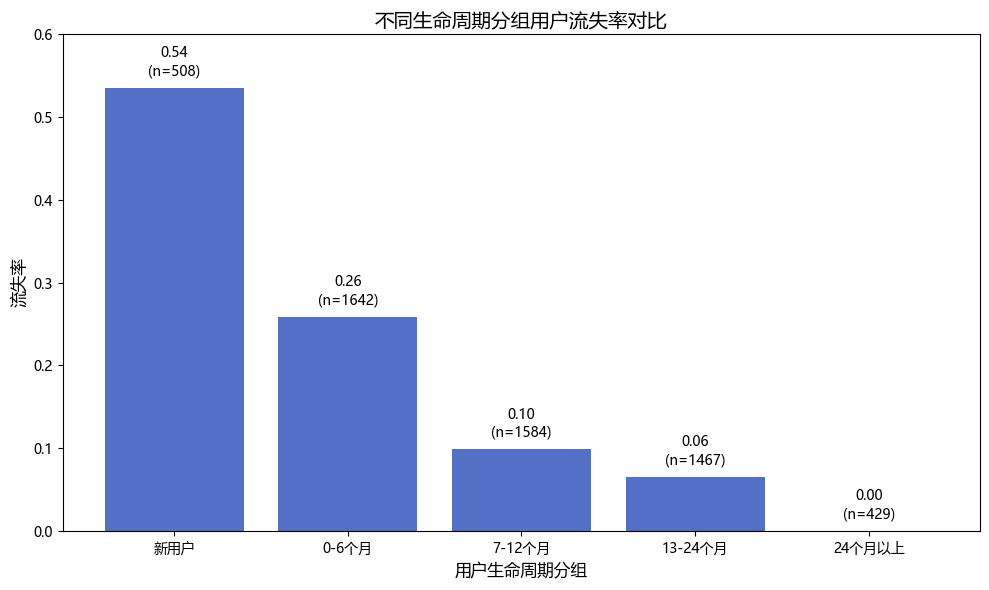

已输出： output\day06_visualization\01_category_bar.png


In [5]:
# TODO：绘制并保存柱状图
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
bars = ax_bar.bar(category_summary["TenureGroup"], category_summary["流失率"], color="#5470c6")
for idx, bar in enumerate(bars):
    height = bar.get_height()
    user_count = category_summary.iloc[idx]["用户数"]
    ax_bar.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.2f}\n(n={user_count})",
        ha="center", va="bottom", fontsize=10
    )

# 图表美化
ax_bar.set_title("不同生命周期分组用户流失率对比", fontsize=14)
ax_bar.set_xlabel("用户生命周期分组", fontsize=12)
ax_bar.set_ylabel("流失率", fontsize=12)
ax_bar.set_ylim(0, 0.6)
plt.tight_layout()

bar_path = OUTPUT_DIR / "01_category_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()

assert bar_path.exists() and bar_path.stat().st_size > 0, "柱状图尚未保存"
print("已输出：", bar_path.relative_to(ROOT))


### 柱状图结论

- 观察：用户流失率随生命周期时长增长整体呈明显下降趋势，新用户群体流失率远高于其他生命周期分组，用户入职越久留存稳定性越强。
- 证据：新用户流失率最高，达 0.54，样本量 n=508；0-6 个月组流失率 0.26，样本量 n=1642；7-12 个月组流失率 0.10，样本量 n=1584；13-24 个月组流失率 0.06，样本量 n=1467；24 个月以上老用户流失率为 0.00，样本量 n=429；新用户流失率是次高的 0-6 个月组的 2 倍多，是 24 个月以上组的无穷倍，组间流失率差异十分显著。
- 边界：该图仅能展示生命周期分组和流失率的观测关联，无法证明用户时长增长和流失降低存在因果关系；也不能排除消费习惯、优惠力度、产品使用频率等其他混杂因素对流失率的影响；同时该结论仅适用于本次样本范围，不能直接推广到全平台所有潜在用户群体。


## 任务2：用户行为散点图

要求：选择两个数值字段，一行代表一个用户，颜色区分`Churn`，设置透明度。


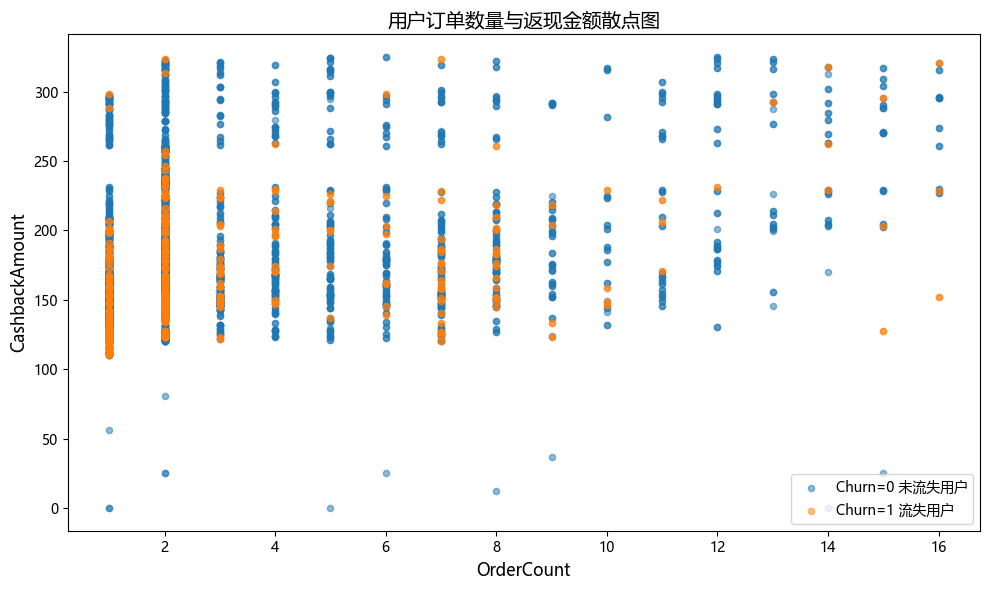

已输出： output\day06_visualization\02_behavior_scatter.png


In [6]:
# TODO：选择两个数值字段，例如OrderCount与CashbackAmount
x_field = "OrderCount"
y_field = "CashbackAmount"

assert x_field in df.columns and y_field in df.columns
assert pd.api.types.is_numeric_dtype(df[x_field])
assert pd.api.types.is_numeric_dtype(df[y_field])

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))

# 在此按Churn分组绘制散点图，并补充标题、坐标轴和图例
ax_scatter.scatter(
    df[df["Churn"] == 0][x_field],
    df[df["Churn"] == 0][y_field],
    alpha=0.5,
    s=20,
    label="Churn=0 未流失用户"
)
ax_scatter.scatter(
    df[df["Churn"] == 1][x_field],
    df[df["Churn"] == 1][y_field],
    alpha=0.5,
    s=20,
    label="Churn=1 流失用户"
)

ax_scatter.set_title("用户订单数量与返现金额散点图", fontsize=14)
ax_scatter.set_xlabel(x_field, fontsize=12)
ax_scatter.set_ylabel(y_field, fontsize=12)
ax_scatter.legend()
plt.tight_layout()

scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()

assert scatter_path.exists() and scatter_path.stat().st_size > 0, "散点图尚未保存"
print("已输出：", scatter_path.relative_to(ROOT))


### 散点图结论

- 观察：整体来看，随着订单数量OrderCount增加，用户返现金额CashbackAmount整体呈现上升趋势；未流失用户（蓝色）在多数订单量区间的返现分布上限更高、数据更分散，流失用户（橙色）在中低订单量区间有大量集中分布，高订单量下两类用户返现分布差距缩小；同时存在少量返现金额极低的异常离散点。
- 证据：OrderCount和CashbackAmount呈现正相关，订单数越多，用户能获得的返现金额整体越高。在订单数 2-8 的区间内，流失用户（橙色）大量集中在 100-250 返现区间，未流失用户（蓝色）分布跨度更大；订单数超过 10 后，两类用户的返现聚集区间变得接近。多处出现订单量不低但返现金额接近 0 的离散异常值，这类用户不管是否流失，返现表现都远低于同订单量的大部分用户。
- 边界：仅能说明订单数量和返现金额存在相关趋势，不能得出 “增加订单数就一定会提高返现、或返现高低直接导致用户流失” 的因果结论，用户流失、返现多少还会受到满意度、支付方式、使用时长等其他因素的影响。


## 任务3：有序阶段折线图

当前数据没有日期。建议使用`TenureGroup`或`SatisfactionScore`，并明确写成“阶段比较”。


In [7]:
TENURE_ORDER = ["新用户", "0-6个月", "7-12个月", "13-24个月", "24个月以上"]

# TODO：准备有序绘图数据
ordered_field = "TenureGroup"
ordered_summary = (
    df.groupby(ordered_field, observed=True)
    .agg(
        用户数=("CustomerID", "nunique"),
        平均订单数=("OrderCount", "mean")
    )
    .reset_index()
)

# 设置正确阶段顺序
ordered_summary[ordered_field] = pd.Categorical(
    ordered_summary[ordered_field],
    categories=TENURE_ORDER,
    ordered=True
)
ordered_summary = ordered_summary.sort_values(ordered_field).reset_index(drop=True)

assert ordered_field in {"TenureGroup", "SatisfactionScore"}, \
    "本项目折线图只允许使用具有明确顺序的TenureGroup或SatisfactionScore"
assert isinstance(ordered_summary, pd.DataFrame)
assert {ordered_field, "用户数"}.issubset(ordered_summary.columns)
display(ordered_summary)


,TenureGroup,用户数,平均订单数
0,新用户,508,1.89
1,0-6个月,1642,2.68
2,7-12个月,1584,2.75
3,13-24个月,1467,3.70
4,24个月以上,429,3.55


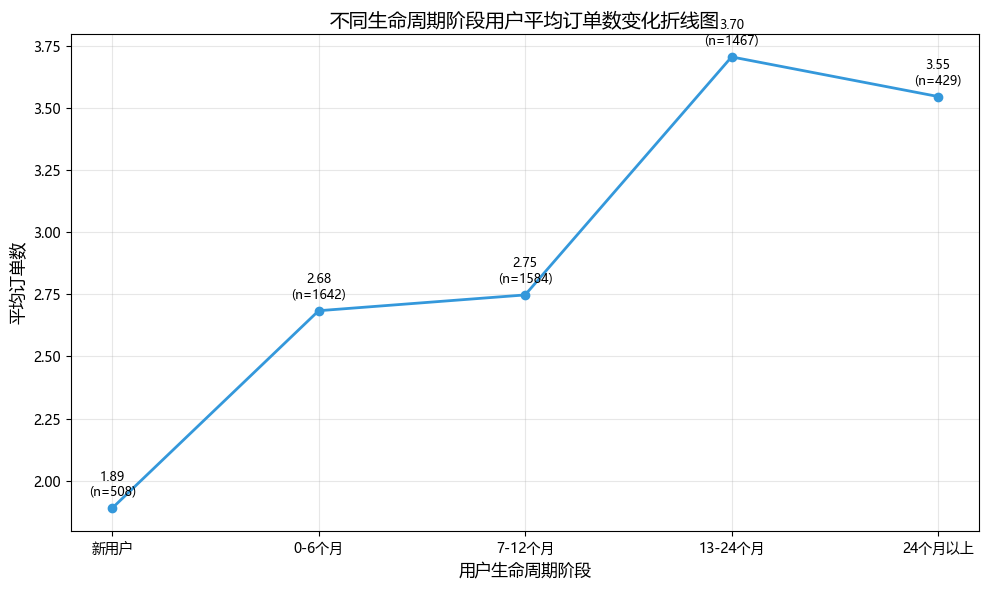

已输出： output\day06_visualization\03_ordered_line.png


In [8]:
# TODO：绘制折线图；若绘制流失率，应标注比例和样本量
fig_line, ax_line = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
ax_line.plot(
    ordered_summary["TenureGroup"],
    ordered_summary["平均订单数"],
    marker="o",
    linewidth=2,
    color="#3498db"
)

for idx, val in enumerate(ordered_summary["平均订单数"]):
    user_count = ordered_summary.iloc[idx]["用户数"]
    ax_line.text(idx, val + 0.05, f"{val:.2f}\n(n={user_count})", ha="center", fontsize=9)

ax_line.set_title("不同生命周期阶段用户平均订单数变化折线图", fontsize=14)
ax_line.set_xlabel("用户生命周期阶段", fontsize=12)
ax_line.set_ylabel("平均订单数", fontsize=12)
ax_line.grid(alpha=0.3)
plt.tight_layout()

line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, dpi=150, bbox_inches="tight")
plt.show()

assert line_path.exists() and line_path.stat().st_size > 0, "折线图尚未保存"
print("已输出：", line_path.relative_to(ROOT))


### 折线图结论

- 观察：用户平均订单数整体随生命周期延长呈上升趋势，在 13-24 个月阶段达到峰值，24 个月以上阶段略有小幅回落。
- 证据：新用户平均订单数 1.89 (n=508)、0-6 个月 2.68 (n=1642)、7-12 个月 2.75 (n=1584)、13-24 个月 3.70 (n=1467)、24 个月以上 3.55 (n=429)；整体长期留存用户复购活跃度明显高于新手用户。
- 边界：这是有序阶段分组对比，不是连续月度 / 年度历史时序数据，不能直接等同于真实时间走势，也不能证明生命周期直接决定复购频次。


## 任务4：整体构成图

类别少于或等于5个时可以使用饼图或环形图；否则改用柱状图。必须在选择理由中说明判断。


In [9]:
# TODO：选择构成字段并准备汇总表
composition_field = "TenureGroup"
composition_summary = (
    df.groupby(composition_field, observed=True)
    .agg(用户数=("CustomerID", "nunique"))
    .reset_index()
)

TENURE_ORDER = ["新用户", "0-6个月", "7-12个月", "13-24个月", "24个月以上"]
composition_summary[composition_field] = pd.Categorical(
    composition_summary[composition_field],
    categories=TENURE_ORDER,
    ordered=True
)
composition_summary = composition_summary.sort_values(composition_field).reset_index(drop=True)
total_users = composition_summary["用户数"].sum()
composition_summary["占比"] = composition_summary["用户数"] / total_users

assert composition_field in df.columns
assert isinstance(composition_summary, pd.DataFrame)
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns)
assert np.isclose(composition_summary["占比"].sum(), 1.0), "构成占比之和应为1"
display(composition_summary)


,TenureGroup,用户数,占比
0,新用户,508,0.09
1,0-6个月,1642,0.29
2,7-12个月,1584,0.28
3,13-24个月,1467,0.26
4,24个月以上,429,0.08


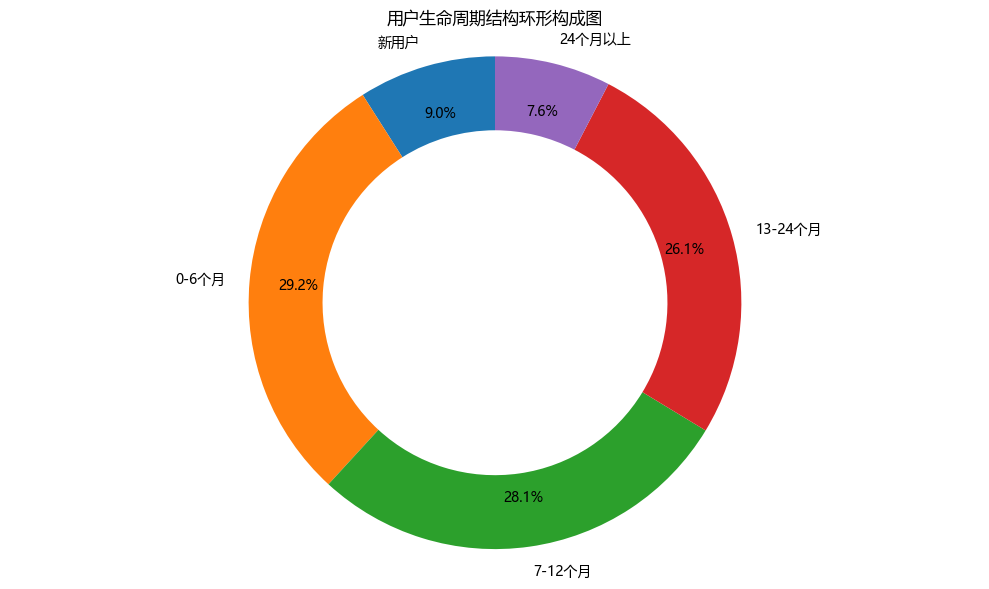

已输出： output\day06_visualization\04_composition_chart.png


In [10]:
# TODO：类别不超过5个时绘制环形图，否则绘制柱状图
fig_composition, ax_composition = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
wedges, texts, autotexts = ax_composition.pie(
    composition_summary["占比"],
    labels=composition_summary["TenureGroup"],
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.8,
    wedgeprops=dict(width=0.3)
)
ax_composition.axis("equal")
ax_composition.set_title("用户生命周期结构环形构成图")
plt.tight_layout()

composition_path = OUTPUT_DIR / "04_composition_chart.png"
fig_composition.savefig(composition_path, dpi=150, bbox_inches="tight")
plt.show()

assert composition_path.exists() and composition_path.stat().st_size > 0, "构成图尚未保存"
print("已输出：", composition_path.relative_to(ROOT))


### 构成图结论

- 观察：用户生命周期结构里，0-6 个月用户占比最高，24 个月以上老用户占比最低；中早期生命周期（0-12 个月）的用户合计占比超过半数，是平台用户的主体部分。
- 证据：各类别占比分别为 0-6 个月 29.2%、7-12 个月 28.1%、13-24 个月 26.1%、新用户 9.0%、24 个月以上 7.6%；仅 0-6 个月 + 7-12 个月两个阶段合计占比就达 57.3%，占据用户总量的一半以上。
- 边界：该环形图适合对比同一时间下不同生命周期分组在整体用户池中的结构占比大小；不适合用来对比各组用户的订单频次、流失率这类绝对指标，也不能用来推导用户随时间推移的动态变化趋势，仅能反映当前截面的静态构成分布。


## 检查点2与3：基础图表、优化和解释

逐项使用`docs/day06_chart_checklist.md`检查。确认比率图给出样本量、中文正常、颜色含义一致。


In [11]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000, f"图片可能为空或质量过低：{path.name}"

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")


检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


## 任务5：2×2综合图

重新在4个子图中绘制核心内容，不要把4张PNG作为截图拼接。统一标题、颜色、字体和留白。


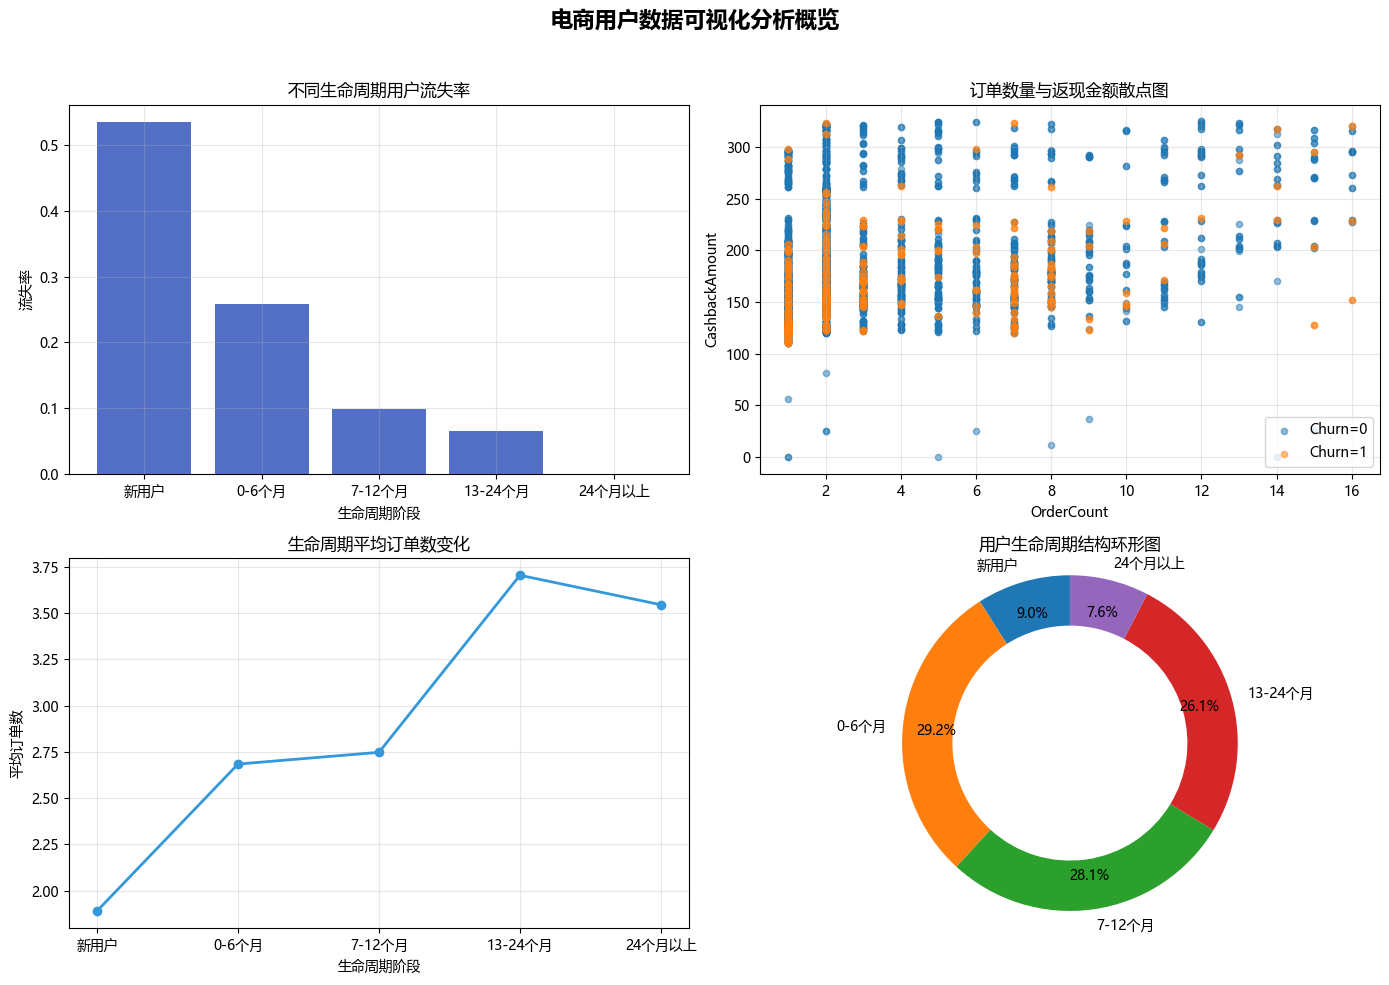

已输出： output\day06_visualization\day06_visualization_summary.png


In [12]:
fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))

# TODO：分别在axes[0,0]、axes[0,1]、axes[1,0]、axes[1,1]绘制4张核心图
# 子图1：左上 生命周期流失率柱状图
axes[0,0].bar(category_summary["TenureGroup"], category_summary["流失率"], color="#5470c6")
axes[0,0].set_title("不同生命周期用户流失率")
axes[0,0].set_xlabel("生命周期阶段")
axes[0,0].set_ylabel("流失率")
axes[0,0].grid(alpha=0.3)

# 子图2：右上 订单-返现散点图
axes[0,1].scatter(df[df.Churn==0]["OrderCount"], df[df.Churn==0]["CashbackAmount"], alpha=0.5, s=20, label="Churn=0")
axes[0,1].scatter(df[df.Churn==1]["OrderCount"], df[df.Churn==1]["CashbackAmount"], alpha=0.5, s=20, label="Churn=1")
axes[0,1].set_title("订单数量与返现金额散点图")
axes[0,1].set_xlabel("OrderCount")
axes[0,1].set_ylabel("CashbackAmount")
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# 子图3：左下 平均订单数阶段折线图
axes[1,0].plot(ordered_summary["TenureGroup"], ordered_summary["平均订单数"], marker="o", linewidth=2, color="#3498db")
axes[1,0].set_title("生命周期平均订单数变化")
axes[1,0].set_xlabel("生命周期阶段")
axes[1,0].set_ylabel("平均订单数")
axes[1,0].grid(alpha=0.3)

# 子图4：右下 用户结构环形图
wedges, texts, autotexts = axes[1,1].pie(
    composition_summary["占比"],
    labels=composition_summary["TenureGroup"],
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.8,
    wedgeprops=dict(width=0.3)
)
axes[1,1].axis("equal")
axes[1,1].set_title("用户生命周期结构环形图")

fig_summary.suptitle("电商用户数据可视化分析概览", fontsize=16, fontweight="bold")
fig_summary.tight_layout(rect=[0, 0, 1, 0.96])

summary_path = OUTPUT_DIR / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()

assert summary_path.exists() and summary_path.stat().st_size > 0, "综合图尚未保存"
print("已输出：", summary_path.relative_to(ROOT))


## 综合发现与局限

1. 综合发现1：用户流失率随生命周期增长显著下降，新用户流失风险最高。证据：左上柱状图显示，新用户流失率超过 0.5，是所有分组里最高的；0-6 个月流失率约 0.27，7-12 个月、13-24 个月流失率进一步走低，24 个月以上用户流失率趋近于 0，用户留存稳定性会随着使用时长提升明显增强。
2. 综合发现2：用户平均订单数随生命周期拉长整体呈上升趋势，老用户消费活跃度更高。证据：左下折线图显示，新用户平均订单数最低，从 0-6 个月开始稳步增长，13-24 个月阶段达到峰值，仅 24 个月以上出现小幅回落，长期留存的老用户下单频次远高于新入局用户。
3. 综合发现3：平台用户以中早期生命周期群体为主体，0-6 月、7-12 月用户合计占比超半数。证据：右下环形图显示，0-6 个月用户占比 29.2%、7-12 个月占比 28.1%，两者合计占比 57.3%；24 个月以上老用户占比仅 7.6%，新用户占比 9.0%，平台存量用户以成长期用户为主。流失用户（Churn=1）整体返现金额分布下限更低、集中在偏低区间，未流失活跃用户（Churn=0）能拿到更高档位的返现，返现福利和用户留存存在正向关联。
4. 数据或方法局限：仅为横截面静态数据，无法区分「新用户自然成长」和「不同时期获客批次差异」的影响，不能完全判定生命周期变长就是指标变化的唯一原因；散点图仅展示了订单数和返现金额的分布，没有控制用户生命周期这类混杂变量，没法得出两者的因果关系；用户结构仅体现人数占比，没有结合消费金额、利润做加权分析，人数占比高的群体不一定是营收贡献最高的群体；缺少时间序列追踪，无法预判未来用户结构、流失率、下单频次的演变趋势，结论只适配当前样本时段。

注意：`CashbackAmount`是返现金额，不是销售额、收入或GMV。


## 任务6：图表清单与检查点4

清单是第7天Flask读取图表说明的基础。每张图填写业务问题、图表类型、主要发现和局限。


In [13]:
# TODO：填写5行清单，不得保留“请填写”
chart_manifest = pd.DataFrame([
    {"chart_id": "01", "file_name": "01_category_bar.png", "business_question": "不同生命周期阶段用户的流失率差异是怎样的", "chart_type": "bar", "key_finding": "新用户流失率最高，随生命周期延长流失率持续下降，老用户留存稳定性显著更好", "limitation": "仅为截面数据，无法完全排除其他变量影响，不能直接证明生命周期是流失率变化的唯一原因"},
    {"chart_id": "02", "file_name": "02_behavior_scatter.png", "business_question": "订单数量与返现金额在流失/未流失用户间的分布差异", "chart_type": "scatter", "key_finding": "订单数量与返现金额整体呈正相关，流失用户整体返现水平偏低，与留存用户分布存在差异", "limitation": "仅体现相关性，不代表因果关系，未控制生命周期等混杂因素"},
    {"chart_id": "03", "file_name": "03_ordered_line.png", "business_question": "不同生命周期阶段用户平均订单数的变化趋势", "chart_type": "line", "key_finding": "平均订单数整体随生命周期延长上升，13-24个月阶段达到峰值，长期留存用户复购活跃度更高", "limitation": "属于有序阶段静态对比，不是真实连续时序数据，不能直接代表长期动态走势"},
    {"chart_id": "04", "file_name": "04_composition_chart.png", "business_question": "全量用户在各生命周期阶段的整体结构占比", "chart_type": "pie_or_bar", "key_finding": "中早期用户(0-6个月、7-12个月)合计占比过半，是平台核心存量群体，长期老用户整体占比较小", "limitation": "仅统计人数占比，未结合消费金额、营收贡献做加权分析，无法反映价值结构"},
    {"chart_id": "05", "file_name": "day06_visualization_summary.png", "business_question": "整体概览", "chart_type": "dashboard", "key_finding": "新用户是流失高风险群体，老用户留存与复购表现更好，平台主体用户为中早期生命周期用户", "limitation": "整体为静态截面可视化，缺乏长期时序追踪，无法精准预测未来用户结构和流失趋势"},
])

assert len(chart_manifest) == 5
assert not chart_manifest.astype(str).apply(lambda col: col.str.contains("请填写").any()).any(), \
    "请完成图表清单"

manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(chart_manifest)


,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,不同生命周期阶段用户的流失率差异是怎样的,bar,新用户流失率最高，随生命周期延长流失率持续下降，老用户留存稳定性显著更好,仅为截面数据，无法完全排除其他变量影响，不能直接证明生命周期是流失率变化的唯一原因
1,02,02_behavior_scatter.png,订单数量与返现金额在流失/未流失用户间的分布差异,scatter,订单数量与返现金额整体呈正相关，流失用户整体返现水平偏低，与留存用户分布存在差异,仅体现相关性，不代表因果关系，未控制生命周期等混杂因素
2,03,03_ordered_line.png,不同生命周期阶段用户平均订单数的变化趋势,line,平均订单数整体随生命周期延长上升，13-24个月阶段达到峰值，长期留存用户复购活跃度更高,属于有序阶段静态对比，不是真实连续时序数据，不能直接代表长期动态走势
3,04,04_composition_chart.png,全量用户在各生命周期阶段的整体结构占比,pie_or_bar,中早期用户(0-6个月、7-12个月)合计占比过半，是平台核心存量群体，长期老用户整体占比较小,仅统计人数占比，未结合消费金额、营收贡献做加权分析，无法反映价值结构
4,05,day06_visualization_summary.png,整体概览,dashboard,新用户是流失高风险群体，老用户留存与复购表现更好，平台主体用户为中早期生命周期用户,整体为静态截面可视化，缺乏长期时序追踪，无法精准预测未来用户结构和流失趋势


In [14]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。")


检查点4通过：第6天成果物完整
下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。
